In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);

In [18]:
# -----------------------------
# 0) Load I/V data
# -----------------------------

# def get_vals(I0, T):
#     '''
#     Run the PyBaMM model and extract the current, voltage, and concentration
#     '''
#     sol, model, param = sim_PyBaMM.simulate_DC1(I0)
#     t = np.linspace(0, sol['Time [s]'].entries[-1], T)
#     I = sol.observe(model.variables['Current [A]'])(t)
#     V = sol.observe(model.variables['Terminal voltage [V]'])(t)
#     cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.
#     cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.


#     return t, V, I, cn, cp

# def gen_data_I_c(B, T):
#     '''
#     B: batch size, T: time steps
#     '''
#     V = np.zeros((B, T, 1)) # 1 channel
#     I = np.zeros((B, T, 1))
#     # I_dot = np.zeros((B, T, 1))
#     cn = np.zeros((B, T, 1))
#     cp = np.zeros((B, T, 1))
#     cn_dot = np.zeros((B, T, 1))
#     cp_dot = np.zeros((B, T, 1))

#     for i in trange(B):
#         t, V[i, :, 0], I[i, :, 0], cn[i, :, 0], cp[i, :, 0] = get_vals(np.random.uniform(0.25, 1.0), T)
        
#         I[i, 0, 0] = 0  # Set initial current to zero for consistency

#         dt = 1  # Override dt to 1 step for simplicity --> cn_dot = cn_delta

#         cn_dot[:, :-1] = np.diff(cn, axis=1)
#         cp_dot[:, :-1] = np.diff(cp, axis=1)
#         # I_dot[:, 1:] = np.diff(I, axis=1) # Backward difference, first time step is zero

#         cn_dot[:, -1] = cn_dot[:, -2]  # Pad last time step with second to last value
#         cp_dot[:, -1] = cp_dot[:, -2]  # Pad last time

#     return I, V, cn, cn_dot, cp, cp_dot

def get_vals(I0, T):
    """
    Run PyBaMM with constant current I0 and sample to T points.
    Returns:
      t, dt, V(t), I(t), cn_surf(t), cp_surf(t)
    """
    sol, model, param = sim_PyBaMM.simulate_DC1(I0)

    t_end = sol["Time [s]"].entries[-1]
    t = np.linspace(0, t_end, T)
    dt = t[1] - t[0]
    print(dt)

    I = sol.observe(model.variables["Current [A]"])(t)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t)

    # these are typically (n_x, T); you take the last x-position as "surface"
    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t)[-1, :]

    return t, dt, V, I, cn, cp, param

def gen_data_I_c(B, T, I_low=0.25, I_high=1.0, seed=None):
    """
    Generates B trajectories of length T at random constant currents.
    Computes c_dot via finite difference / dt.
    """
    rng = np.random.default_rng(seed)

    V = np.zeros((B, T, 1))
    I = np.zeros((B, T, 1))
    cn = np.zeros((B, T, 1))
    cp = np.zeros((B, T, 1))
    cn_dot = np.zeros((B, T, 1))
    cp_dot = np.zeros((B, T, 1))

    last_param = None

    for i in trange(B):
        I0 = float(rng.uniform(I_low, I_high))
        t, dt, V_i, I_i, cn_i, cp_i, param = get_vals(I0, T)

        V[i, :, 0] = V_i
        I[i, :, 0] = I_i
        cn[i, :, 0] = cn_i
        cp[i, :, 0] = cp_i

        # start currents from 0
        I[i, 0, 0] = 0

        # Proper time derivative (backward/forward diff)
        cn_dot[i, :-1, 0] = np.diff(cn[i, :, 0]) / dt
        cp_dot[i, :-1, 0] = np.diff(cp[i, :, 0]) / dt

        # pad last entry
        cn_dot[i, -1, 0] = cn_dot[i, -2, 0]
        cp_dot[i, -1, 0] = cp_dot[i, -2, 0]

        last_param = param

    return I, V, cn, cn_dot, cp, cp_dot, dt, last_param

In [19]:
# one run to get T if you want to tie it to model horizon
sol0, model0, param0 = sim_PyBaMM.simulate_DC1(0.5)
T = 1000 # int(sol0["Time [s]"].entries[-1])  # if this is huge, consider using e.g. 1000 instead
print("T =", T)

B = 10
I, V, cn, cn_dot, cp, cp_dot, dt, param = gen_data_I_c(B, T, seed=0)

# np.savez("data_c_dot_constantI.npz", I=I, V=V, cn=cn, cn_dot=cn_dot, cp=cp, cp_dot=cp_dot, dt=dt)

# Or load:
# d = np.load("data_c_dot_constantI.npz")
# I, V, cn, cn_dot, cp, cp_dot = d["I"], d["V"], d["cn"], d["cn_dot"], d["cp"], d["cp_dot"]
# dt = float(d["dt"])

T = 1000


  0%|          | 0/10 [00:00<?, ?it/s]

3.3864489342103057


 30%|███       | 3/10 [00:00<00:00,  7.88it/s]

3.6036036036036037
3.6036036036036037


...

3.6036036036036037
2.853218589157044
2.6190020894762682


 80%|████████  | 8/10 [00:00<00:00,  9.59it/s]

3.4983567544084493
3.0844983266289385
3.6036036036036037


100%|██████████| 10/10 [00:01<00:00,  8.71it/s]

2.571513305180398


In [4]:
# -----------------------------
# 1) Scaling
# -----------------------------

''' Scale Mark 1 '''
sol, model, param = sim_PyBaMM.simulate_DC1(0.5)
cn_max = param['Maximum concentration in negative electrode [mol.m-3]']
cn_scale = cn_max
cn_dot_scale = np.max(np.abs(cn_dot))  # Scale cn_dot by its max absolute value to get range ~[-1, 1]

cn_s = cn / cn_scale
cn_dot_s = cn_dot / cn_dot_scale    # ≠ cn_dot_train_s = scale(cn_dot_train, MinMaxScaler())

print(f"cn_scale: {cn_scale}, cn_dot_scale: {cn_dot_scale}")
print(I.shape, cn_s.shape, cn_dot_s.shape)
print(f"cn range: [{cn_s.min():.2f}, {cn_s.max():.2f}]"
      f", cn_dot range: [{cn_dot_s.min():.2f}, {cn_dot_s.max():.2f}]")

cn_scale: 24983.2619938437, cn_dot_scale: 36.622496631513656
(100, 1000, 1) (100, 1000, 1) (100, 1000, 1)
cn range: [0.17, 0.80], cn_dot range: [-1.00, -0.04]


In [5]:
''' Split data '''
# Split batches
test_size = 0.1
split = int(test_size * B)

def split_data(data, split):
    return data[:split], data[split:]

# Split and convert to float32 for PyTorch
I_test, I_train = split_data(I, split)
cn_test_s, cn_train_s = split_data(cn_s, split)
cn_dot_test_s, cn_dot_train_s = split_data(cn_dot_s, split)

V_test, V_train = split_data(V, split)

train_dataset = TensorDataset(torch.tensor(I_train, dtype=torch.float32),    # Not using scaled 
                              torch.from_numpy(cn_train_s).float(), 
                              torch.from_numpy(cn_dot_train_s).float())

batch_size = int((B*0.9)/6)
loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
for I_batch, cn_batch, cn_dot_batch in loader:
    print(I_batch.shape, cn_batch.shape, cn_dot_batch.shape)
    break

torch.Size([15, 1000, 1]) torch.Size([15, 1000, 1]) torch.Size([15, 1000, 1])


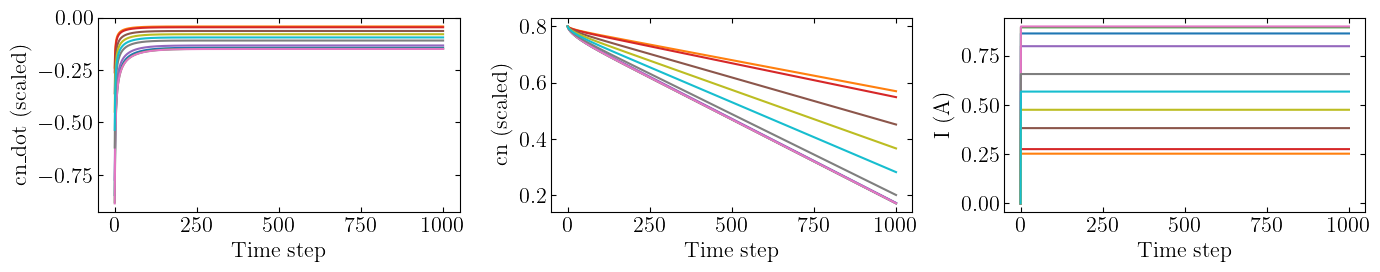

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 3))

for idb in range(min(10, cn_train_s.shape[0])):
    ax1.plot(cn_dot_train_s[idb, :, 0])
    ax2.plot(cn_train_s[idb, :, 0])
    ax3.plot(I_train[idb, :, 0])

ax1.set_ylabel("cn_dot (scaled)")
ax2.set_ylabel("cn (scaled)")
ax3.set_ylabel("I (A)")
for ax in (ax1, ax2, ax3):
    ax.set_xlabel("Time step")
plt.tight_layout()

In [7]:
# -----------------------------
# 2) Network
# -----------------------------
class Net(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=2, out_features=hidden_dim), # input i_t, c_t
            nn.Tanh(),
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),  # output c_dot_k
        )

    def forward(self, I, c):
        # x: [B*T, 1], c: [B*T, 1]
        x = torch.cat([I, c], dim=-1)  # [B*T, 2]
        output = self.net(x)
        return output
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

In [8]:
# -----------------------------
# 3) Training loop
# -----------------------------


''' Mark 2: Unrolled training '''
# def training(epochs=50):
#     history = {"loss": []}
#     for ep in range(epochs):
#         model.train()
#         last = None

#         for I_batch, cn_batch, cn_dot_batch in loader:

#             optimizer.zero_grad()

#             loss = 0
#             dt=1

#             K = 40  # Time steps to unroll
#             s = torch.randint(0, T-K-1, (1,)).item()    # Random start index for unrolling
#             c_pred = cn_batch[:, s, :]

#             for k in range(K):

#                 I_k = I_batch[:, s+k, :]          # shape (B,1)

#                 c_dot_hat = model(I_k, c_pred)

#                 c_pred = c_pred + dt * c_dot_hat    # Euler forward

#                 c_true = cn_batch[:, s+k+1, :]  # shape (B,1)

#                 loss += mse(c_pred, c_true)

#             loss.backward()
#             optimizer.step()
#             last = loss.item()

#         history["loss"].append(last)

#         print(f'Epoch {ep+1} | loss {last} |')

#     return history

' Mark 2: Unrolled training '

In [9]:
def training(epochs=30):
    history = {"loss": []}
    for ep in range(epochs):
        model.train()
        last = None

        for I_batch, cn_batch, cn_dot_batch in loader:
            I_flat = I_batch.reshape(-1, 1)
            cn_flat = cn_batch.reshape(-1, 1)
            y_flat = cn_dot_batch.reshape(-1, 1)

            pred = model(I_flat, cn_flat)
            loss = mse(pred, y_flat)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            last = loss.item()

        history["loss"].append(last)
        print(f"Epoch {ep+1:02d} | loss {last:.3e}")

    return history

history = training(epochs=30)

Epoch 01 | loss 8.407e-03
Epoch 02 | loss 1.069e-03
Epoch 03 | loss 1.436e-03
Epoch 04 | loss 2.088e-03
Epoch 05 | loss 1.440e-03
Epoch 06 | loss 1.115e-03
Epoch 07 | loss 1.388e-03
Epoch 08 | loss 8.021e-04
Epoch 09 | loss 1.054e-03
Epoch 10 | loss 1.180e-03
Epoch 11 | loss 1.010e-03
Epoch 12 | loss 1.055e-03
Epoch 13 | loss 1.016e-03
Epoch 14 | loss 9.347e-04
Epoch 15 | loss 1.030e-03
Epoch 16 | loss 8.363e-04
Epoch 17 | loss 1.287e-03
Epoch 18 | loss 1.038e-03
Epoch 19 | loss 1.054e-03
Epoch 20 | loss 1.072e-03
Epoch 21 | loss 1.274e-03
Epoch 22 | loss 1.030e-03
Epoch 23 | loss 1.221e-03
Epoch 24 | loss 1.281e-03
Epoch 25 | loss 1.125e-03
Epoch 26 | loss 1.022e-03
Epoch 27 | loss 1.175e-03
Epoch 28 | loss 1.001e-03
Epoch 29 | loss 1.121e-03
Epoch 30 | loss 1.274e-03


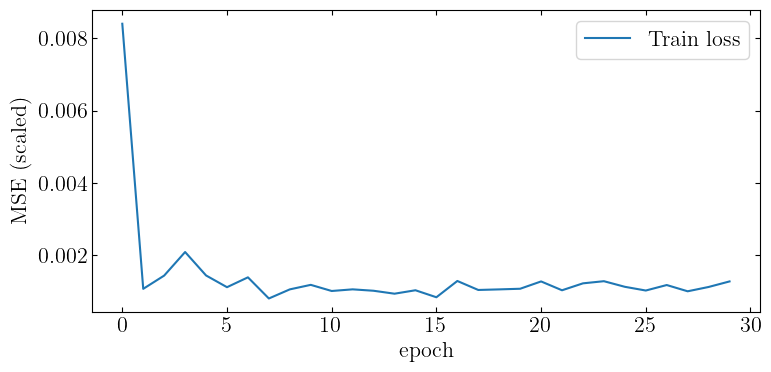

In [10]:
# -----------------------------
# 4) Test + plot
# -----------------------------

fig, (ax1) = plt.subplots(1, 1, figsize=(8, 4))

ax1.plot(history["loss"], label="Train loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE (scaled)")
ax1.legend()

plt.tight_layout()

In [11]:
def rollout(idx=0):
    model.eval()
    cn_euler = np.zeros_like(cn_test_s)  # (B,T,1)

    cn_euler[idx, 0, 0] = cn_test_s[idx, 0, 0]

    cn_dot_hat_list = []
    dt = 1
    with torch.no_grad():
        for t in range(T-1):
            I_t = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)
            c_t = torch.tensor([[cn_euler[idx, t, 0]]], dtype=torch.float32)

            c_dot_hat = model(I_t, c_t).item()  # scaled 1/s
            cn_euler[idx, t+1, 0] = cn_euler[idx, t, 0] + dt * c_dot_hat
            cn_dot_hat_list.append(c_dot_hat)

    return cn_euler, np.array(cn_dot_hat_list)

idx = 0
cn_euler, cn_dot_hat_list = rollout(idx)

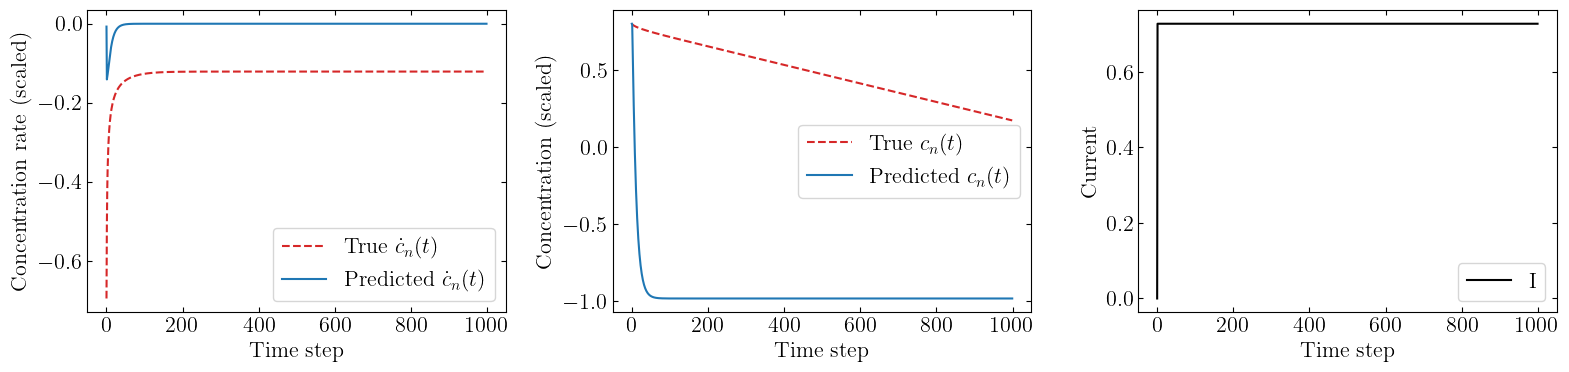

In [12]:
''' Plot '''
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(cn_dot_test_s[idx, :, 0],  color="tab:red", linestyle="dashed", label="True $\\dot{c}_n(t)$")
ax1.plot(cn_dot_hat_list, color="tab:blue", label="Predicted $\\dot{c}_n(t)$")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Concentration rate (scaled)")
ax1.legend()

ax2.plot(cn_test_s[idx, :, 0], color="tab:red", linestyle="dashed", label="True $c_n(t)$")
ax2.plot(cn_euler[idx, :, 0], color="tab:blue", label="Predicted $c_n(t)$")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Concentration (scaled)")
ax2.legend()

ax3.plot(I_test[idx, :, 0], label='I', color='black')
ax3.set_xlabel("Time step")
ax3.set_ylabel("Current")
ax3.legend()

plt.tight_layout()